In [2]:
%pip install SpeechRecognition pydub librosa soundfile noisereduce
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import glob
import json
import time
import uuid
import pickle
import warnings
from typing import List, Dict, Any, Optional, Union, Sequence

# Audio processing
import librosa
import soundfile as sf
import noisereduce as nr
from scipy import signal
import scipy.fftpack
from pydub import AudioSegment
import speech_recognition as sr

# Machine learning
import networkx as nx
from sklearn.base import BaseEstimator
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import BaggingClassifier , VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt


warnings.filterwarnings('ignore')


Note: you may need to restart the kernel to use updated packages.


## Graph-Data-Structure Naive Bayes



\begin{aligned}
\hat{y} &= \underset{y \in \mathcal{Y}}{\arg\max} \, P(y \mid \mathbf{x}) \\
&= \underset{y \in \mathcal{Y}}{\arg\max} \, \frac{P(\mathbf{x} \mid y) \, P(y)}{P(\mathbf{x})} \\
&= \underset{y \in \mathcal{Y}}{\arg\max} \, P(\mathbf{x} \mid y) \, P(y) \qquad \text{(Dropping denominator \(P(\mathbf{x})\) as it's constant)} \\
&= \underset{y \in \mathcal{Y}}{\arg\max} \, \left( \prod_{i=1}^{n} P(x_i \mid y) \right) P(y) \qquad \text{(Naive assumption: features are independent given class)} \\
&= \underset{y \in \mathcal{Y}}{\arg\max} \, \log\left[ \left( \prod_{i=1}^{n} P(x_i \mid y) \right) P(y) \right] \qquad \text{(Taking log, which preserves argmax)} \\
&= \underset{y \in \mathcal{Y}}{\arg\max} \, \left[ \log P(y) + \sum_{i=1}^{n} \log P(x_i \mid y) \right] \qquad \text{(Log of product equals sum of logs)} \\
\\

\end{aligned}


In [3]:
class Node:
    def __init__(self, name: str):
        if not isinstance(name, str):
            raise TypeError("Node name must be a string.")
        self.name: str = name
        self.children: List['Node'] = []
        self.parents: List['Node'] = []

    def add_child(self, child: 'Node') -> None:
        if not isinstance(child, Node):
            raise TypeError("Child must be an instance of Node or its subclass.")
        self.children.append(child)
        child.parents.append(self)

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(name='{self.name}')"

class ClassNode(Node):
    def __init__(self, name: str, classes: np.ndarray):
        super().__init__(name)
        if not isinstance(classes, np.ndarray):
            raise TypeError("Classes must be a numpy array.")
        self.classes: np.ndarray = classes
        self.priors: Dict[Any, float] = {}

    def fit(self, y: np.ndarray) -> Dict[Any, float]:
        if not isinstance(y, np.ndarray):
            raise TypeError("Target labels y must be a numpy array.")
        if y.ndim != 1:
            raise ValueError("Target labels y must be a 1D array.")

        total_samples: int = len(y)
        if total_samples == 0:
            print("Warning: Fitting ClassNode with empty data.")
            for c in self.classes:
                self.priors[c] = 1.0 / len(self.classes)
            return self.priors

        for c in self.classes:
            class_count: int = np.sum(y == c)
            self.priors[c] = class_count / total_samples

        if not np.isclose(sum(self.priors.values()), 1.0):
             print(f"Warning: Prior probabilities do not sum to 1 (sum={sum(self.priors.values())}). Check data.")

        return self.priors

class FeatureNode(Node):
    def __init__(self, name: str, feature_index: int):
        super().__init__(name)
        if not isinstance(feature_index, int) or feature_index < 0:
             raise ValueError("Feature index must be a non-negative integer.")
        self.feature_index: int = feature_index
        self.conditionals: Dict[Any, Dict[str, float]] = {}
        self._epsilon: float = 1e-9

    def fit(self, X: np.ndarray, y: np.ndarray, classes: np.ndarray) -> Dict[Any, Dict[str, float]]:
        if not isinstance(X, np.ndarray) or X.ndim != 2:
             raise TypeError("Input data X must be a 2D numpy array.")
        if not isinstance(y, np.ndarray) or y.ndim != 1:
             raise TypeError("Target labels y must be a 1D numpy array.")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Number of samples in X and y must match.")
        if self.feature_index >= X.shape[1]:
             raise ValueError(f"Feature index {self.feature_index} is out of bounds for data with {X.shape[1]} features.")

        for c in classes:
            features_c: np.ndarray = X[y == c, self.feature_index]

            if features_c.size == 0:
                print(f"Warning: No samples found for class '{c}' when fitting feature '{self.name}'. Setting default parameters.")
                mean = np.mean(X[:, self.feature_index])
                var = np.var(X[:, self.feature_index]) + self._epsilon
            elif features_c.size == 1:
                 mean = features_c[0]
                 var = self._epsilon
                 print(f"Warning: Only one sample found for class '{c}' when fitting feature '{self.name}'. Using epsilon for variance.")
            else:
                mean: float = np.mean(features_c)
                var: float = np.var(features_c) + self._epsilon

            self.conditionals[c] = {'mean': mean, 'var': var}

        return self.conditionals

    def _gaussian_pdf(self, x: float, mean: float, var: float) -> float:
        if var <= 0:
             print(f"Warning: Non-positive variance ({var}) encountered in Gaussian PDF calculation for feature '{self.name}'.")
             return 0.0
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var)
        exponent = -((x - mean) ** 2) / (2.0 * var)
        return coeff * np.exp(exponent)

    def probability(self, x: float, class_value: Any) -> float:
        if class_value not in self.conditionals:
            print(f"Warning: Unknown class '{class_value}' requested for feature '{self.name}'. Returning small probability.")
            return self._epsilon

        params = self.conditionals[class_value]
        mean = params['mean']
        var = params['var']

        prob = self._gaussian_pdf(x, mean, var)

        return max(prob, self._epsilon)


class NaiveBayesGraph(BaseEstimator):
    def __init__(self):
        self.class_node: Optional[ClassNode] = None
        self.feature_nodes: List[FeatureNode] = []
        self.classes: Optional[np.ndarray] = None
        self.graph = nx.DiGraph()

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'NaiveBayesGraph':
        if not isinstance(X, np.ndarray) or X.ndim != 2:
             raise TypeError("Input data X must be a 2D numpy array.")
        if not isinstance(y, np.ndarray) or y.ndim != 1:
             raise TypeError("Target labels y must be a 1D numpy array.")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Number of samples in X and y must match.")
        if X.shape[0] == 0:
            raise ValueError("Cannot fit model with empty data.")

        n_samples, n_features = X.shape

        self.classes = np.unique(y)
        if self.classes.size < 2:
             print(f"Warning: Only found {self.classes.size} class(es) in the data. Naive Bayes is typically used for multi-class problems.")

        self.class_node = ClassNode('Class', self.classes)
        self.graph.add_node('Class', node_type='class', obj=self.class_node)
        self.class_node.fit(y)

        self.feature_nodes = []
        for i in range(n_features):
            feature_name = f'X{i}'
            feature_node = FeatureNode(feature_name, i)
            self.feature_nodes.append(feature_node)

            self.class_node.add_child(feature_node)

            self.graph.add_node(feature_name, node_type='feature', index=i, obj=feature_node)
            self.graph.add_edge('Class', feature_name)

            feature_node.fit(X, y, self.classes)
        self.classes_ = self.classes

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.class_node is None or not self.feature_nodes or self.classes is None:
            raise RuntimeError("Model has not been fitted yet. Call fit() first.")
        if not isinstance(X, np.ndarray) or X.ndim != 2:
             raise TypeError("Input data X must be a 2D numpy array.")
        if X.shape[1] != len(self.feature_nodes):
             raise ValueError(f"Input data has {X.shape[1]} features, but model was trained with {len(self.feature_nodes)} features.")

        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probas = np.zeros((n_samples, n_classes))

        for i, sample in enumerate(X):
            for j, c in enumerate(self.classes):
                prior_prob = self.class_node.priors.get(c, 0.0)
                log_prior = np.log(prior_prob + 1e-12)
                log_likelihood = 0.0

                for feature_node in self.feature_nodes:
                    feature_value = sample[feature_node.feature_index]
                    cond_prob = feature_node.probability(feature_value, c)
                    log_likelihood += np.log(cond_prob)

                log_probas[i, j] = log_prior + log_likelihood

        max_log_probas = np.max(log_probas, axis=1, keepdims=True)
        max_log_probas = np.where(np.isinf(max_log_probas), 0, max_log_probas)

        probas = np.exp(log_probas - max_log_probas)

        sum_probas = np.sum(probas, axis=1, keepdims=True)
        probas = np.divide(probas, sum_probas, out=np.zeros_like(probas), where=sum_probas!=0)

        uniform_prob = 1.0 / n_classes
        probas[sum_probas.flatten() == 0] = uniform_prob

        return probas

    def predict(self, X: np.ndarray) -> np.ndarray:
        probas = self.predict_proba(X)
        return self.classes[np.argmax(probas, axis=1)]


## Audio Processing

In [ ]:
def extract_features(file_path, n_mfcc=13, max_length=None):
    """Extract features from an audio file."""
    try:
        # Load audio file
        if file_path.endswith('.m4a'):
            # Convert file if needed
            temp_wav = file_path.replace('.m4a', '.wav')
            os.system(f'ffmpeg -i "{file_path}" -y "{temp_wav}" -loglevel quiet')
            file_to_process = temp_wav
            converted = True
        else:
            file_to_process = file_path
            converted = False

        # Preprocess audio
        y_processed, sr = preprocess_audio(file_to_process)

        # 1. Extract MFCCs and deltas
        hop_length = 512
        n_fft = 2048
        mfcc = librosa.feature.mfcc(y=y_processed, sr=sr, hop_length=hop_length, n_mfcc=n_mfcc, n_fft=n_fft)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

        # 2. Extract spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y_processed, sr=sr, hop_length=hop_length, n_fft=n_fft)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y_processed, sr=sr, hop_length=hop_length, n_fft=n_fft)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y_processed, sr=sr, hop_length=hop_length, n_fft=n_fft)

        # 3. Extract temporal features
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y_processed, hop_length=hop_length)

        # 4. Extract energy features
        rms = librosa.feature.rms(y=y_processed, hop_length=hop_length)

        # 5. Extract chroma features
        chroma = librosa.feature.chroma_stft(y=y_processed, sr=sr, hop_length=hop_length, n_fft=n_fft)

        # Create feature vector
        features = []

        # Add MFCC features
        for i in range(n_mfcc):
            features.extend([
                np.mean(mfcc[i]), np.std(mfcc[i]), np.min(mfcc[i]), np.max(mfcc[i]),
                np.mean(mfcc_delta[i]), np.std(mfcc_delta[i]), np.min(mfcc_delta[i]), np.max(mfcc_delta[i]),
                np.mean(mfcc_delta2[i]), np.std(mfcc_delta2[i]), np.min(mfcc_delta2[i]), np.max(mfcc_delta2[i])
            ])

        # Add spectral features
        spectral_features = [
            spectral_centroid, spectral_bandwidth, spectral_rolloff,
            zero_crossing_rate, rms
        ]

        for feat in spectral_features:
            features.extend([np.mean(feat), np.std(feat), np.min(feat), np.max(feat)])

        # Add chroma features
        for i in range(12):  # 12 chroma features
            features.extend([np.mean(chroma[i]), np.std(chroma[i]), np.min(chroma[i]), np.max(chroma[i])])

        # Add pitch related features (fundamental frequency estimation)
        pitches, magnitudes = librosa.piptrack(y=y_processed, sr=sr, n_fft=n_fft, hop_length=hop_length)
        pitch_mean = np.mean(pitches[pitches > 0]) if np.any(pitches > 0) else 0
        pitch_std = np.std(pitches[pitches > 0]) if np.any(pitches > 0) else 0
        features.extend([pitch_mean, pitch_std])

        # Clean up if we converted the file
        if converted:
            os.remove(temp_wav)

        return np.array(features)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        # Clean up if we converted the file
        if 'converted' in locals() and converted and 'temp_wav' in locals():
            if os.path.exists(temp_wav):
                os.remove(temp_wav)
        return None


def preprocess_audio(wavfile):
    """Preprocess audio with noise reduction, silence removal, and normalization."""
    # Load audio file
    y, sr = librosa.load(wavfile, sr=None)

    # 1. Noise reduction
    # Estimate noise from a portion assumed to be noise (first 1000 samples or adjust as needed)
    noise_sample = y[:1000] if len(y) > 1000 else y[:len(y)//10]
    y_reduced = nr.reduce_noise(y=y, sr=sr, y_noise=noise_sample, prop_decrease=0.8)

    # 2. Silence removal
    # Compute energy/amplitude
    energy = librosa.feature.rms(y=y_reduced)[0]
    threshold = 0.005  # Adjust based on your needs
    silence_mask = energy > threshold

    # Find regions with sound
    regions = []
    in_region = False
    region_start = 0

    for i, is_sound in enumerate(silence_mask):
        if is_sound and not in_region:
            in_region = True
            region_start = i
        elif not is_sound and in_region:
            in_region = False
            regions.append((region_start, i))

    if in_region:
        regions.append((region_start, len(silence_mask)))

    # Reconstruct audio without silence
    if regions:
        hop_length = 512  # Match the hop_length used in rms calculation
        y_no_silence = np.concatenate([y_reduced[r[0]*hop_length:r[1]*hop_length] for r in regions])
    else:
        y_no_silence = y_reduced  # If no regions found, keep the noise-reduced audio

    # 3. Normalization
    y_normalized = librosa.util.normalize(y_no_silence)

    return y_normalized, sr


def audio_time_features(filename, timesplit=0.50):
    try:
        # Load audio file
        y, sr = librosa.load(filename)
        duration = float(librosa.core.get_duration(y))

        # Now splice an audio signal into individual elements and extract features
        segnum = max(1, round(duration/timesplit))
        deltat = duration/segnum

        # Create time segments
        timesegment = [i * deltat * 1000 for i in range(segnum + 1)]

        # Load audio with pydub for segmentation
        newAudio = AudioSegment.from_wav(filename)

        # List to store filenames of temporary segments
        filelist = []

        # Create directory for temp files if it doesn't exist
        temp_dir = os.path.join(os.getcwd(), 'temp_segments')
        os.makedirs(temp_dir, exist_ok=True)

        # Process each segment
        for i in range(len(timesegment)-1):
            # Create temporary filename with UUID to avoid conflicts
            temp_filename = os.path.join(temp_dir, f"{uuid.uuid4()}_segment.wav")

            # Export segment to temporary file
            segment = newAudio[timesegment[i]:timesegment[i+1]]
            segment.export(temp_filename, format="wav")
            filelist.append(temp_filename)

        # Initialize features array
        segment_features = np.zeros((len(filelist), 1))  # Will resize later based on actual feature count

        # Extract features from each segment
        for i, segment_file in enumerate(filelist):
            try:
                features = extract_features(segment_file)

                # Resize array if this is the first segment (now we know the feature count)
                if i == 0:
                    segment_features = np.zeros((len(filelist), len(features)))

                segment_features[i] = features

                # Remove temporary file
                os.remove(segment_file)
            except Exception as e:
                print(f"Error processing segment {i}: {e}")
                os.remove(segment_file)

        # Calculate mean features across all segments
        mean_features = np.mean(segment_features, axis=0)

        # Calculate other statistics (similar to original code)
        std_features = np.std(segment_features, axis=0)
        min_features = np.min(segment_features, axis=0)
        max_features = np.max(segment_features, axis=0)

        # Combine statistics into a single feature vector
        combined_features = np.concatenate([
            mean_features,
            std_features,
            min_features,
            max_features
        ])

        return combined_features

    except Exception as e:
        print(f"Error extracting time features from {filename}: {e}")
        return None


def convert(file):
    # Check if file is already WAV
    if file.endswith('.wav'):
        return file

    supported_extensions = ['.mp3', '.m4a', '.ogg', '.flac']
    file_ext = os.path.splitext(file)[1].lower()

    if file_ext in supported_extensions:
        # Create output filename
        filename = os.path.splitext(file)[0] + '.wav'

        try:
            # Convert using ffmpeg if available
            if os.system('ffmpeg -h >/dev/null 2>&1') == 0:
                os.system(f'ffmpeg -i "{file}" "{filename}" -y -loglevel error')
            else:
                # Fallback to pydub for conversion
                audio = AudioSegment.from_file(file)
                audio.export(filename, format="wav")

            print(f"Converted {file} to {filename}")
            return filename
        except Exception as e:
            print(f"Error converting {file}: {e}")
            return file
    else:
        # Unsupported format
        print(f"Unsupported file format: {file}")
        return None


def save_features_to_csv(features_list, output_file):
    # Create feature names
    feature_names = [
        'mean', 'std', 'max_abs', 'zcr', 'rms', 'fundamental_freq',
        'spectral_centroid', 'spectral_rolloff', 'spectral_flatness',
        'spectral_bandwidth', 'spectral_contrast'
    ]

    # Add MFCC feature names
    n_mfcc = 13  # Same as in extract_features
    for i in range(n_mfcc):
        feature_names.append(f'mfcc_{i}')

    # Add delta MFCC feature names
    for i in range(n_mfcc):
        feature_names.append(f'delta_mfcc_{i}')

    # Add delta2 MFCC feature names
    for i in range(n_mfcc):
        feature_names.append(f'delta2_mfcc_{i}')

    # Add band energy feature names
    for i in range(n_mfcc):
        feature_names.append(f'band_energy_{i}')

    # Extract features and labels
    features = [item[0] for item in features_list]
    labels = [item[1] for item in features_list]

    # Create DataFrame
    df = pd.DataFrame(features, columns=feature_names)
    df['label'] = labels

    # Save to CSV
    df.to_csv(output_file, index=False)
    print(f"Features saved to {output_file}")
    return df


def load_features_from_csv(csv_file):
    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file)
        # Separate features and labels
        labels = df['label'].values
        features = df.drop('label', axis=1).values

        # Convert to the same format as process_audio_directory output
        features_list = [(features[i], labels[i]) for i in range(len(features))]
        return features_list
    else:
        return None


def process_audio_directory(directory, label=None):

    # List of supported audio extensions
    supported_extensions = ['.wav', '.mp3', '.m4a', '.ogg', '.flac']

    # List to store features and labels
    features_list = []

    # Process each file in directory
    for file in os.listdir(directory):
        file_path = os.path.join(directory, file)

        # Skip directories
        if os.path.isdir(file_path):
            continue

        # Check if file is an audio file
        file_ext = os.path.splitext(file_path)[1].lower()
        if file_ext not in supported_extensions:
            continue

        try:
            # Convert to WAV if needed
            wav_file = convert(file_path)
            if wav_file is None:
                continue

            # Extract features
            features = extract_features(wav_file)

            # Add time-based features
            time_features = audio_time_features(wav_file)
            if time_features is not None:
                # Combine both feature sets
                combined_features = np.concatenate([features, time_features])
            else:
                combined_features = features

            # Determine label (either provided or from filename)
            if label is None:
                # Try to extract label from filename or parent directory
                file_label = os.path.splitext(file)[0]
                parent_dir = os.path.basename(directory)
                file_label = parent_dir  # Default to parent directory name
            else:
                file_label = label

            # Add to features list
            features_list.append((combined_features, file_label))

            print(f"Processed {file} with label: {file_label}")

        except Exception as e:
            print(f"Error processing {file}: {e}")

    return features_list


def process_directory_to_csv(directory, gender_label=None, output_csv='audio_features.csv', append=False):
    """Process all audio files in a directory and save features to CSV."""
    # Create column names for the CSV
    column_names = []

    # MFCC feature names (13 MFCCs, each with mean, std, min, max for original, delta, delta2)
    for i in range(13):
        for stat in ['mean', 'std', 'min', 'max']:
            column_names.append(f'mfcc_{i}_{stat}')
            column_names.append(f'mfcc_delta_{i}_{stat}')
            column_names.append(f'mfcc_delta2_{i}_{stat}')

    # Spectral feature names
    for feat in ['centroid', 'bandwidth', 'rolloff', 'zero_crossing_rate', 'rms']:
        for stat in ['mean', 'std', 'min', 'max']:
            column_names.append(f'spectral_{feat}_{stat}')

    # Chroma feature names
    for i in range(12):
        for stat in ['mean', 'std', 'min', 'max']:
            column_names.append(f'chroma_{i}_{stat}')

    # Pitch features
    column_names.extend(['pitch_mean', 'pitch_std'])

    # Find all audio files in the directory
    files = []
    for ext in ['.wav', '.mp3', '.m4a', '.flac', '.ogg']:
        files.extend(glob.glob(os.path.join(directory, f"*{ext}")))

    if not files:
        print(f"No audio files found in {directory}")
        return

    total_files = len(files)
    print(f"Found {total_files} audio files in {directory}")

    # Create a list to store all feature vectors
    all_features = []
    all_filenames = []

    # Process each file
    for i, file_path in enumerate(files):
        print(f"Processing file {i+1}/{total_files}: {os.path.basename(file_path)}")
        features = extract_features(file_path)

        if features is not None:
            all_features.append(features)
            all_filenames.append(os.path.basename(file_path))

    # Create a DataFrame from the features
    df = pd.DataFrame(all_features, columns=column_names)

    # Add filename column
    df.insert(0, 'filename', all_filenames)

    # Add gender label if provided
    if gender_label is not None:
        df.insert(1, 'gender', gender_label)

    # Save to CSV
    if append and os.path.exists(output_csv):
        # Append without header if file exists
        df.to_csv(output_csv, mode='a', header=False, index=False)
        print(f"Added {len(df)} entries to {output_csv}")
    else:
        # Create new file with header
        df.to_csv(output_csv, index=False)
        print(f"Created new CSV file {output_csv} with {len(df)} entries")

    return df


In [ ]:
# Paths to your male and female voice datasets
male_dir = "VoxCeleb_gender/VoxCeleb_gender/males"
female_dir = "VoxCeleb_gender/VoxCeleb_gender/females"



# Process male directory
print("Processing male audio files...")
process_directory_to_csv(male_dir,gender_label='male', output_csv='audio_features.csv')

# Process female directory (append to the same CSV)
print("Processing female audio files...")
process_directory_to_csv(female_dir,gender_label='female', output_csv='audio_features.csv', append=True)

print("Processing complete. Features saved to audio_features.csv")

Processing male audio files...
Found 3682 audio files in VoxCeleb_gender/VoxCeleb_gender/males
Processing file 1/3682: 2426.m4a
Processing file 2/3682: 1943.m4a
Processing file 3/3682: 2292.m4a
Processing file 4/3682: 839.m4a
Processing file 5/3682: 1037.m4a
Processing file 6/3682: 2126.m4a
Processing file 7/3682: 1103.m4a
Processing file 8/3682: 3270.m4a
Processing file 9/3682: 1453.m4a
Processing file 10/3682: 2476.m4a
Processing file 11/3682: 1683.m4a
Processing file 12/3682: 1100.m4a
Processing file 13/3682: 3164.m4a
Processing file 14/3682: 1168.m4a
Processing file 15/3682: 2561.m4a
Processing file 16/3682: 2196.m4a
Processing file 17/3682: 1612.m4a
Processing file 18/3682: 3288.m4a
Processing file 19/3682: 2718.m4a
Processing file 20/3682: 112.m4a
Processing file 21/3682: 1266.m4a
Processing file 22/3682: 2584.m4a
Processing file 23/3682: 3216.m4a
Processing file 24/3682: 1762.m4a
Processing file 25/3682: 2028.m4a
Processing file 26/3682: 1210.m4a
Processing file 27/3682: 1466.m4

/home/ammarmorad/anaconda3/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1536
  warnings.warn(


Processing file 776/3682: 311.m4a
Processing file 777/3682: 820.m4a
Processing file 778/3682: 991.m4a
Processing file 779/3682: 493.m4a
Processing file 780/3682: 1158.m4a
Processing file 781/3682: 1530.m4a
Processing file 782/3682: 3662.m4a
Processing file 783/3682: 1722.m4a
Processing file 784/3682: 1351.m4a
Processing file 785/3682: 1649.m4a
Processing file 786/3682: 3444.m4a
Processing file 787/3682: 97.m4a
Processing file 788/3682: 1316.m4a
Processing file 789/3682: 2585.m4a
Processing file 790/3682: 1240.m4a
Processing file 791/3682: 3550.m4a
Processing file 792/3682: 1167.m4a
Processing file 793/3682: 2867.m4a
Processing file 794/3682: 99.m4a
Processing file 795/3682: 1224.m4a
Processing file 796/3682: 1826.m4a
Processing file 797/3682: 556.m4a
Processing file 798/3682: 564.m4a
Processing file 799/3682: 811.m4a
Processing file 800/3682: 2676.m4a
Processing file 801/3682: 1855.m4a
Processing file 802/3682: 1026.m4a
Processing file 803/3682: 3183.m4a
Processing file 804/3682: 3537.

In [7]:
def load_and_prepare_data(csv_file, gender_column='gender', filename_column='filename'):
    """
    Load feature data from CSV and prepare for training.

    Args:
        csv_file: Path to the CSV file
        gender_column: Name of the column containing gender labels
        filename_column: Name of the column containing filenames

    Returns:
        X: Feature matrix
        y: Target vector
        feature_names: List of feature names
        scaler: Fitted StandardScaler object
        gender_mapping: Dictionary mapping gender labels to numeric values
    """
    print(f"Loading data from {csv_file}...")

    # Load the CSV file
    df = pd.read_csv(csv_file)

    # Check if required columns exist
    if gender_column not in df.columns:
        raise ValueError(f"Gender column '{gender_column}' not found in CSV")

    # Convert text labels to numeric if necessary
    if df[gender_column].dtype == 'object':
        # Create mapping dictionary (e.g., 'male' -> 0, 'female' -> 1)
        gender_mapping = {label: idx for idx, label in enumerate(df[gender_column].unique())}

        # Map text labels to numeric values
        df['gender_numeric'] = df[gender_column].map(gender_mapping)

        # Display the mapping for reference
        print("Gender mapping:")
        for label, value in gender_mapping.items():
            print(f"  {label} -> {value}")
    else:
        # Use the existing numeric column
        df['gender_numeric'] = df[gender_column]
        gender_mapping = None

    # Separate features from target and filenames
    exclude_columns = [col for col in [gender_column, 'gender_numeric', filename_column] if col in df.columns]
    feature_columns = [col for col in df.columns if col not in exclude_columns]

    # Extract features and target
    X = df[feature_columns].values
    y = df['gender_numeric'].values

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"Data loaded: {X.shape[0]} samples with {X.shape[1]} features")

    return X_scaled, y, feature_columns, scaler, gender_mapping

In [8]:
# Load and prepare your data
X, y, feature_names, scaler , gender_mapping = load_and_prepare_data("audio_features.csv")

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

Loading data from audio_features.csv...
Gender mapping:
  male -> 0
  female -> 1
Data loaded: 5988 samples with 226 features


Training individual models for baseline comparison...


Training Bagging with Naive Bayes...
Training Bagging with Logistic Regression...
Training Bagging with Logistic Regression on Naive Bayes predictions...

Naive Bayes (Baseline) Results:
Accuracy: 0.8971
Precision: 0.8508
Recall: 0.8993
F1 Score: 0.8744

Logistic Regression (Baseline) Results:
Accuracy: 0.9259
Precision: 0.9048
Recall: 0.9094
F1 Score: 0.9071

Bagging with Naive Bayes Results:
Accuracy: 0.8864
Precision: 0.8179
Recall: 0.9195
F1 Score: 0.8657

Bagging with Logistic Regression Results:
Accuracy: 0.9218
Precision: 0.9012
Recall: 0.9027
F1 Score: 0.9019

Voting based on Bagging Logistic Regression and Naive Bayes Results:
Accuracy: 0.9185
Precision: 0.9086
Recall: 0.8842
F1 Score: 0.8963


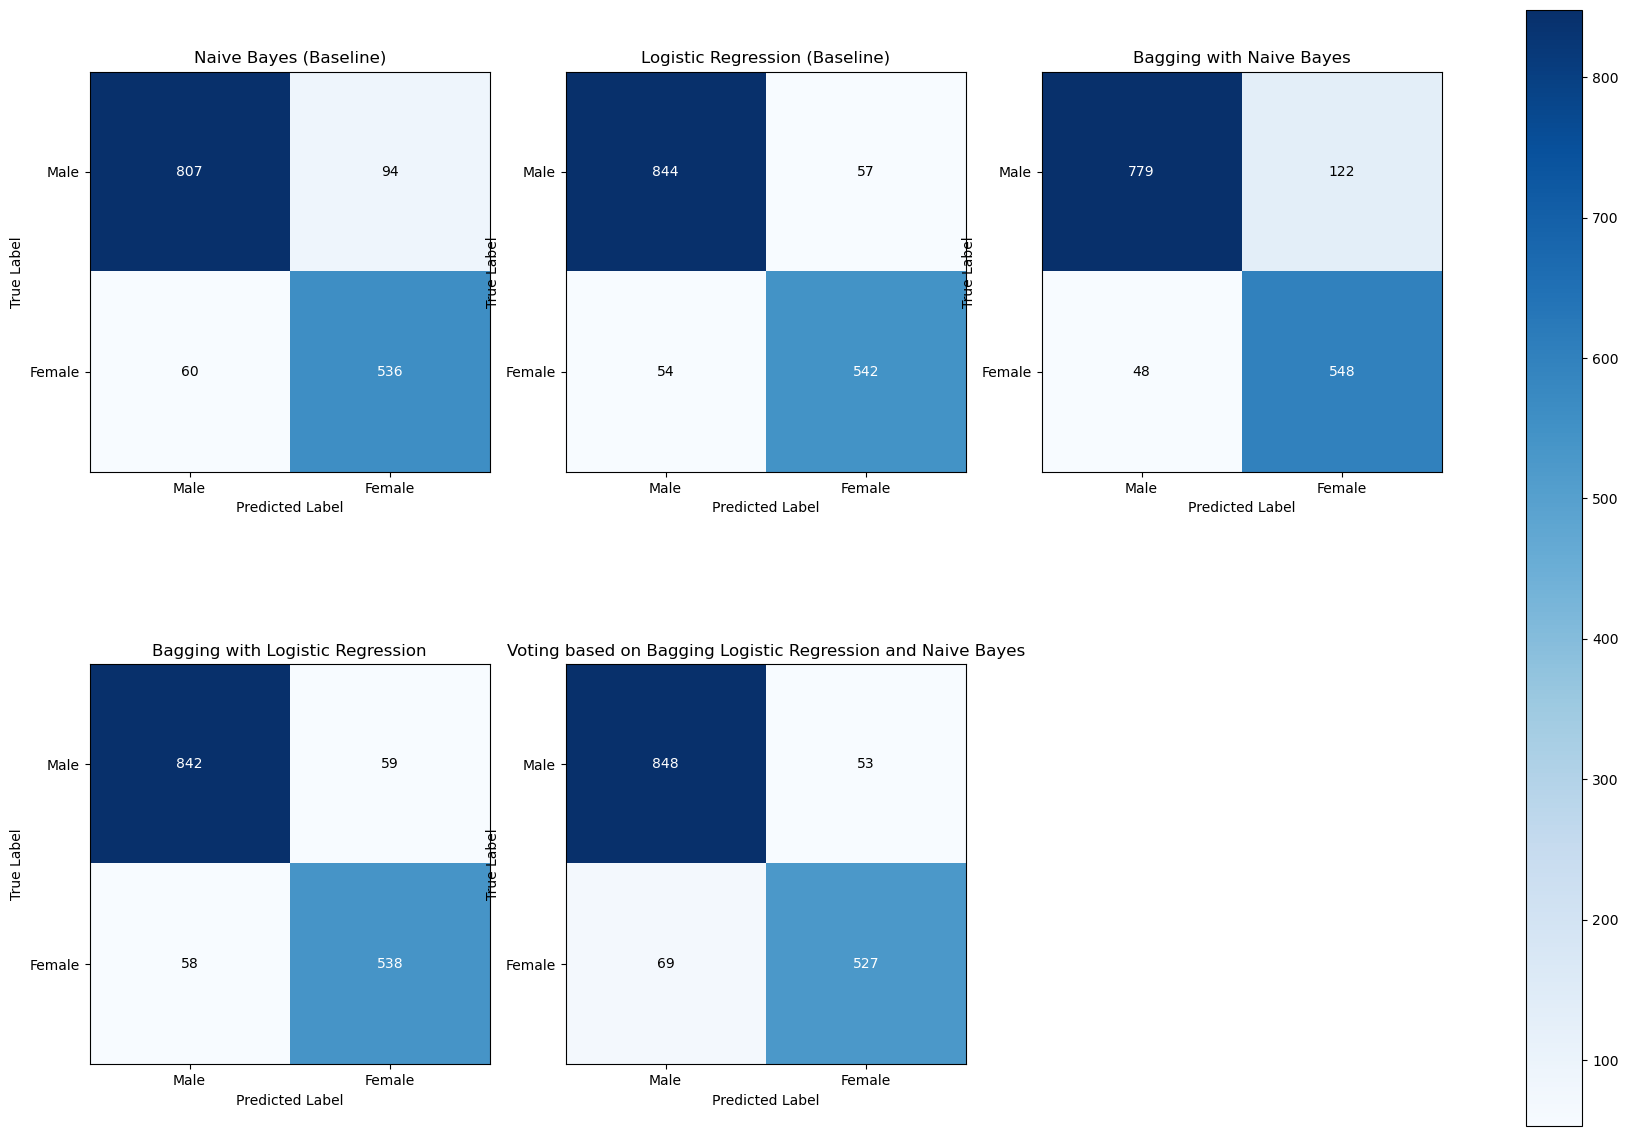

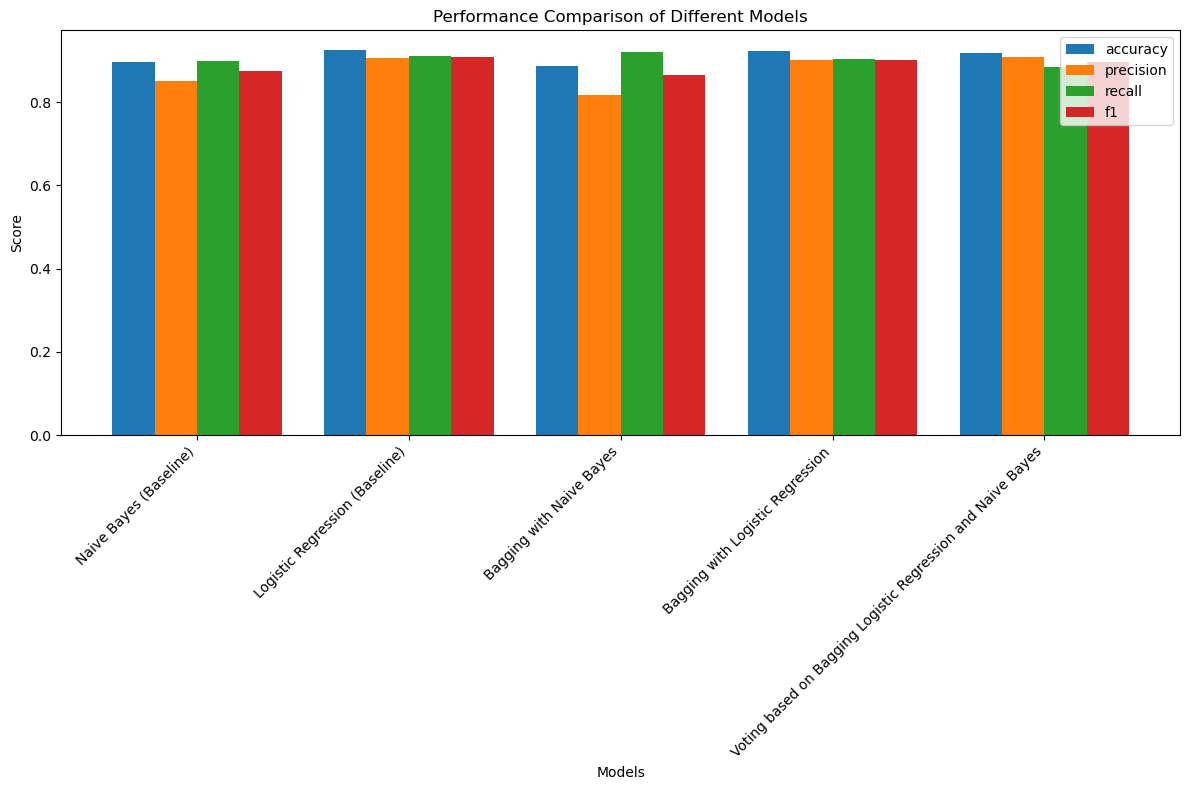

In [9]:
# 1. Individual models for baseline comparison
print("Training individual models for baseline comparison...")

# Naive Bayes baseline
nb_baseline = NaiveBayesGraph()
nb_baseline.fit(X_train, y_train)
y_pred_nb = nb_baseline.predict(X_test)

# Logistic Regression baseline
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)
y_pred_lr = lr_baseline.predict(X_test)

# 2. Bagging with Naive Bayes
print("Training Bagging with Naive Bayes...")
bagging_nb = BaggingClassifier(
    estimator=NaiveBayesGraph(),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)
bagging_nb.fit(X_train, y_train)
y_pred_bagging_nb = bagging_nb.predict(X_test)

# 3. Bagging with Logistic Regression
print("Training Bagging with Logistic Regression...")
bagging_lr = BaggingClassifier(
    estimator=LogisticRegression(max_iter=1000),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)
bagging_lr.fit(X_train, y_train)
y_pred_bagging_lr = bagging_lr.predict(X_test)

# 4. Bagging NB with Logistic Regression
print("Training Bagging with Logistic Regression on Naive Bayes predictions...")
voting_lr_nb = VotingClassifier(
    estimators=[
        ('bagging_nb', bagging_nb),
        ('bagging_lr', bagging_lr)
    ],
    voting='hard'
)
voting_lr_nb.fit(X_train, y_train)
y_pred_bagging_lr_nb = voting_lr_nb.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_nb, "Naive Bayes (Baseline)"))
results.append(evaluate_model(y_test, y_pred_lr, "Logistic Regression (Baseline)"))
results.append(evaluate_model(y_test, y_pred_bagging_nb, "Bagging with Naive Bayes"))
results.append(evaluate_model(y_test, y_pred_bagging_lr, "Bagging with Logistic Regression"))
results.append(evaluate_model(y_test, y_pred_bagging_lr_nb, "Voting based on Bagging Logistic Regression and Naive Bayes"))

# Plot confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, result in enumerate(results):
    if i < len(axes):  # Make sure we don't exceed the number of axes
        cm = result['confusion_matrix']
        ax = axes[i]
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(result['model'])

        # Add text annotations to the confusion matrix
        thresh = cm.max() / 2
        for j in range(cm.shape[0]):
            for k in range(cm.shape[1]):
                ax.text(k, j, format(cm[j, k], 'd'),
                        ha="center", va="center",
                        color="white" if cm[j, k] > thresh else "black")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Male', 'Female'])
        ax.set_yticklabels(['Male', 'Female'])
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

# Hide any unused subplots
for i in range(len(results), len(axes)):
    axes[i].axis('off')

fig.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist())
plt.show()

# Plot performance comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = [r['model'] for r in results]

fig, ax = plt.subplots(figsize=(12, 8))
bar_width = 0.2
r = np.arange(len(model_names))

for i, metric in enumerate(metrics):
    values = [result[metric] for result in results]
    ax.bar(r + i * bar_width, values, width=bar_width, label=metric)

ax.set_xlabel('Models')
ax.set_xticks(r + bar_width * (len(metrics) - 1) / 2)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison of Different Models')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
nb_baseline.predict(X_test[147].reshape(1, -1))[0]
X_test[147]

array([-9.68616934e-01,  7.26064163e-01, -5.78764358e-01,  3.84814483e-01,
       -8.52132298e-01,  1.21975523e+00, -1.34588980e-02,  2.10011954e+00,
        5.72337758e-01,  1.06335267e+00, -1.24478238e+00,  1.46124470e+00,
       -1.90011940e-01,  1.04270838e-01, -1.69507229e-03, -2.07591758e-01,
       -5.35174128e-01,  4.20896222e-01, -9.74602141e-01, -2.14879477e-01,
        2.13015228e-02,  2.20190312e-01, -1.18129062e+00,  3.27871138e-02,
        7.30114492e-01,  1.21949130e+00, -3.36883198e-01,  1.06867522e+00,
        1.79183563e+00,  1.55209179e+00, -8.20410019e-01,  9.51755415e-01,
        1.69826205e-01,  1.68003130e+00, -1.13858539e+00,  8.53972334e-01,
        9.49918240e-01, -2.96272617e-01,  1.48723418e+00,  2.28635160e+00,
        4.70862243e-01, -3.65095968e-01, -6.77309075e-01,  8.99335332e-01,
       -1.06765693e+00,  8.38389411e-01, -1.05536203e+00, -9.58652386e-02,
        5.64782028e-03,  1.28703529e+00, -1.14580201e+00, -4.49937820e-01,
        2.18491247e+00,  

In [10]:
def predict_with_all_models(sample, scaler, gender_mapping=None, models=None):
    """
    Test a sample with multiple models and display the results.

    Args:
        sample: Feature vector from extract_features function
        scaler: Fitted StandardScaler object
        gender_mapping: Dictionary mapping gender labels to numeric values
        models: Dictionary of model names and model objects
    """
    # Make sure sample is properly shaped
    if len(sample.shape) == 1:
        sample = sample.reshape(1, -1)

    # Scale the sample using the same scaler used for training
    sample_scaled = scaler.transform(sample)

    if models is None:
        models = {
            "lr_baseline": lr_baseline,
            "nb_baseline": nb_baseline,
            "bagging_lr": bagging_lr,
            "bagging_nb": bagging_nb
        }

    print("\nPredictions for the audio sample:")
    print("-" * 40)

    for name, model in models.items():
        # Get numeric prediction
        prediction_numeric = model.predict(sample_scaled)[0]

        # Get prediction probabilities if supported
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(sample_scaled)[0]
            prob_str = f" (Confidence: {max(probabilities):.2f})"
        else:
            probabilities = None
            prob_str = ""

        # Convert to label if mapping exists
        if gender_mapping is not None:
            reverse_mapping = {v: k for k, v in gender_mapping.items()}
            gender = reverse_mapping.get(prediction_numeric, str(prediction_numeric))
        else:
            gender = "Female" if prediction_numeric == 1 else "Male"

        print(f"{name}: {gender}{prob_str}")

        # Show detailed probabilities if available
        if probabilities is not None:
            print("  Probabilities:")
            for i, prob in enumerate(probabilities):
                class_name = list(gender_mapping.keys())[i] if gender_mapping else ("Male" if i == 0 else "Female")
                print(f"    {class_name}: {prob:.4f}")

    return sample_scaled

In [21]:
!pip install pvrecorder
import struct
import wave
from pvrecorder import PvRecorder

recorder = PvRecorder(device_index=-1 , frame_length=512)
audio = []

try:
    recorder.start()
    print("Recording... Press Ctrl+C to stop.")
    while True:
        frame = recorder.read()
        audio.extend(frame)
except KeyboardInterrupt:
    print("Recording stopped.")
finally:
    recorder.stop()

with wave.open("output.wav", "wb") as wf:
    wf.setparams((1, 2, 16000, 0, "NONE", "NONE"))
    wf.writeframes(struct.pack("h" * len(audio), *audio))

print("Recording saved as output.wav.")


Recording... Press Ctrl+C to stop.
Recording stopped.
Recording saved as output.wav.


In [11]:
# Extract features from audio file
sample = extract_features("output.wav")

# Define your models dictionary if not using the defaults
models = {
    "Logistic Regression": lr_baseline,
    "Naive Bayes": nb_baseline,
    "Bagging with LR": bagging_lr,
    "Bagging with NB": bagging_nb,
}

# Test the sample with all models
predict_with_all_models(sample, scaler, gender_mapping, models)


Predictions for the audio sample:
----------------------------------------
Logistic Regression: male (Confidence: 1.00)
  Probabilities:
    male: 0.9999
    female: 0.0001
Naive Bayes: male (Confidence: 1.00)
  Probabilities:
    male: 1.0000
    female: 0.0000
Bagging with LR: male (Confidence: 1.00)
  Probabilities:
    male: 0.9993
    female: 0.0007
Bagging with NB: male (Confidence: 1.00)
  Probabilities:
    male: 1.0000
    female: 0.0000


array([[ 1.63142274e-01,  2.89010476e-01,  1.05533904e+00,
         7.80214710e-01,  7.51648352e-01,  9.50035743e-01,
        -1.45543618e+00,  5.04092223e-02, -2.38893907e+00,
        -5.35420202e-01,  1.19199713e+00, -7.15119766e-01,
         4.12689509e-01, -3.91326036e-01,  1.24555348e+00,
         2.60998630e-01, -1.11785245e+00,  1.68516023e-02,
         1.67417984e-01, -1.45447299e+00,  2.50963984e+00,
        -6.11966701e-01,  9.38540313e-01, -1.11252811e+00,
         4.31998953e-01, -1.27353477e+00,  7.81889107e-01,
        -1.06741880e+00, -6.77874637e-01, -7.97957194e-01,
         9.89170668e-01, -1.42945981e+00,  3.57066890e-01,
        -1.96631293e+00,  2.52152713e+00, -1.59829277e+00,
         9.13032891e-01, -1.65665984e+00,  2.21735733e+00,
        -1.01396438e+00, -1.09270422e+00, -2.64637682e+00,
         2.37973196e+00, -2.70429355e+00, -4.77109777e-02,
        -2.58909051e+00,  2.17102585e+00, -2.65726998e+00,
         9.88078265e-01, -1.20963394e+00,  1.90207693e+0